In [16]:
from matplotlib.pyplot import subplots, legend
from scipy.signal import sosfilt, sosfreqz
from scipy.fft import fft
from urllib.request import urlopen
from IPython.display import Audio
from findDigitalFilterIIRBiquadsByTargetFreq import findDigitalFilterIIRBiquadsByTargetFreq, formatBiquadsAsStaticFloats
import soundfile as sf
import pandas as pd
import numpy as np
import io

In [17]:
data, samplerate = sf.read(io.BytesIO(urlopen("http://www.w3schools.com/html/horse.ogg").read()))
Audio(data[:,0], rate=samplerate)

In [18]:
sos, fc, f_comp = findDigitalFilterIIRBiquadsByTargetFreq(fDesejada=1500, ordem=4, fs=samplerate, filterType="lowpass", plot=False) # Filtro rejeita-faixa (bandstop) entre 1500 e 2100 Hz, filterType pode ser: bandpass, lowpass, highpass, bandstop
filtered_data = sosfilt(sos, data[:,0])
Audio(filtered_data, rate=samplerate)

Resultado do filtro IIR em biquads:
  Tipo: lowpass
  Ordem: 4
  Frequencia(s) desejada(s): 1500.0 Hz
  Frequencia(s) de corte: 1900.6435156292189
  Frequencia(s) complementar(es): 3174.155331657298
  Magnitude alvo/obtida: 0.950000000 / 0.950000000


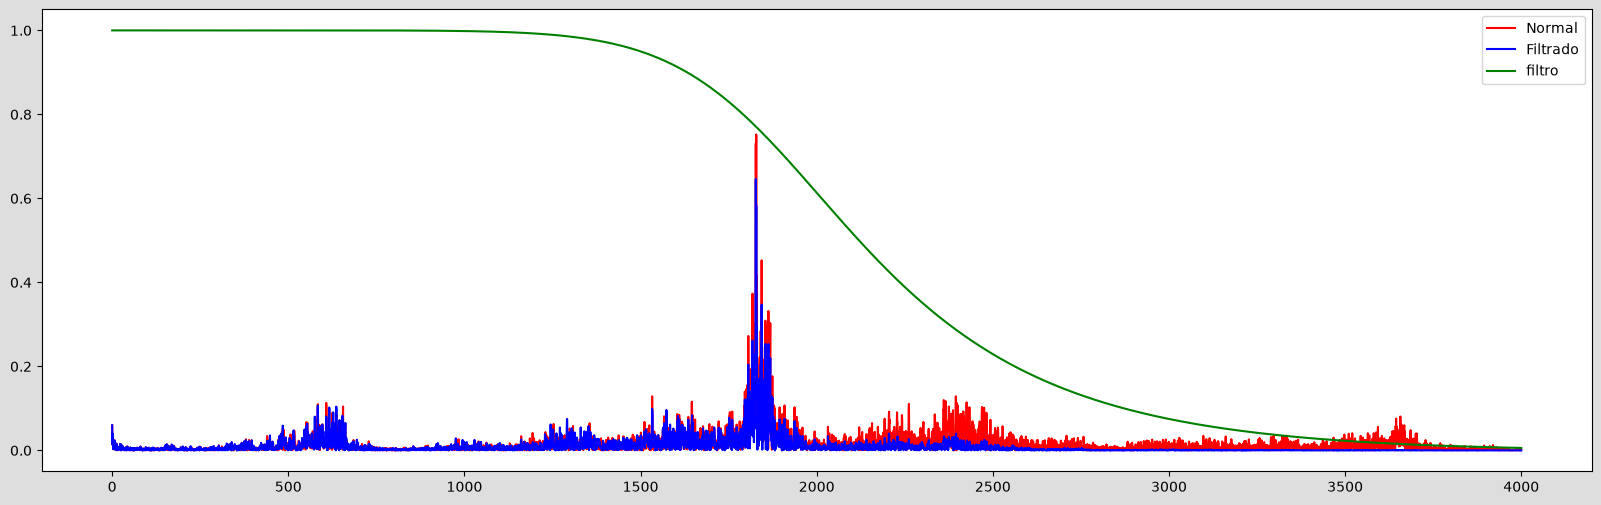

In [19]:
fig, ax = subplots(figsize=(20,6), facecolor='#DEDEDE')

fmax = 4000#samplerate//2 # // -> Divisão inteira, trunca para o menor inteiro mais proximo.
tsamples = (np.size(data[:,0],axis=0)*fmax)//samplerate

x = np.linspace(0, fmax, tsamples)
y = fft(data[:,0])[:tsamples]
yf = fft(filtered_data[0:])[:tsamples]

w, h = sosfreqz(sos, worN=x, fs = samplerate)
ymax = max([max(abs(y)), max(abs(yf))])
line1, line2, line3 = ax.plot(np.real(x), abs(np.real(y/ymax)),"r",np.real(x), abs(np.real(yf/ymax)),"b",np.real(x), abs(h), 'g')
legend([line1,line2, line3],["Normal","Filtrado", "filtro"])

In [20]:
print(formatBiquadsAsStaticFloats(sos, prefixo="lowpass_stage"))

static float lowpass_stage1_coeffs[5] = {
    0.029058182199822265f,
    0.05811636439964453f,
    0.029058182199822265f,
    -0.5159313372981117f,
    0.1011974058740317f,
};

static float lowpass_stage2_coeffs[5] = {
    1.0f,
    2.0f,
    1.0f,
    -0.7002830914282003f,
    0.49467548859626914f,
};

static float lowpass_stage1_state[2] = {0.0f, 0.0f};

static float lowpass_stage2_state[2] = {0.0f, 0.0f};
